In [302]:
# 必要なライブラリのimport
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Tensorflow
import tensorflow as tf

# データの分割
from sklearn.model_selection import train_test_split

# DataFrameで全ての列を表示する設定
pd.options.display.max_columns = None

In [303]:
# Kaggleのデータセット "Uber Ride Analytics Dataset 2024"を使う。
# https://www.kaggle.com/datasets/yashdevladdha/uber-ride-analytics-dashboard

# CSVファイルを読み込む
dataset_base = pd.read_csv("./ncr_ride_bookings.csv")
dataset_base.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [304]:
# データセットの各項目名と（有効な）件数を確認
dataset_base.count()

Date                                 150000
Time                                 150000
Booking ID                           150000
Booking Status                       150000
Customer ID                          150000
Vehicle Type                         150000
Pickup Location                      150000
Drop Location                        150000
Avg VTAT                             139500
Avg CTAT                             102000
Cancelled Rides by Customer           10500
Reason for cancelling by Customer     10500
Cancelled Rides by Driver             27000
Driver Cancellation Reason            27000
Incomplete Rides                       9000
Incomplete Rides Reason                9000
Booking Value                        102000
Ride Distance                        102000
Driver Ratings                        93000
Customer Rating                       93000
Payment Method                       102000
dtype: int64

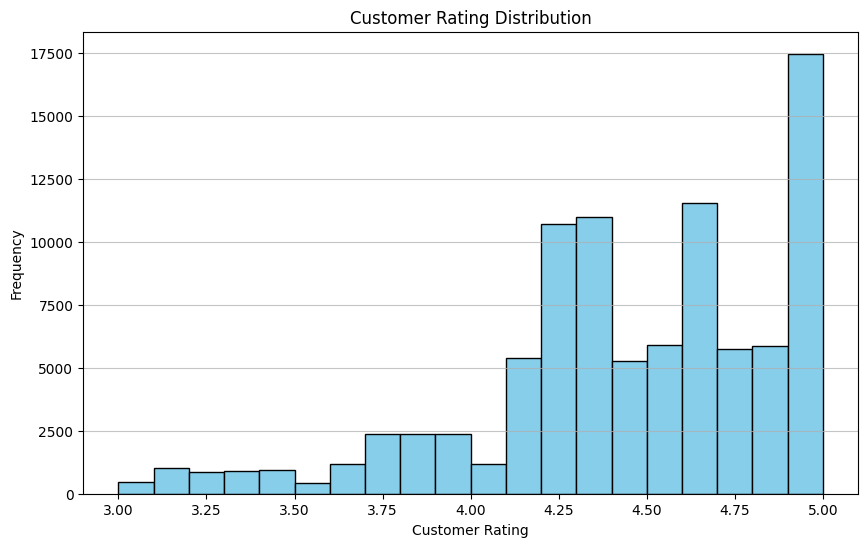

In [305]:
# 目的変数の候補として、"Customer Rating"に注目することにした。まずデータセットから分布を確認する。
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(dataset_base["Customer Rating"], bins=20, color='skyblue', edgecolor='black')
plt.title("Customer Rating Distribution")
plt.xlabel("Customer Rating")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)
plt.show()

# 今回は、"Customer Rating"が5であるか否かを予測する二値分類問題とする。

In [306]:
# 説明変数の検討を行う。
# "Vehicle Type", "Pickup Location", "Drop Location", "Payment Method"のユニークな値の件数を確認する。
print("Vehicle Typeのユニークな値の件数:", len(dataset_base["Vehicle Type"].unique()))
print("Pickup Locationのユニークな値の件数:", len(dataset_base["Pickup Location"].unique()))
print("Drop Locationのユニークな値の件数:", len(dataset_base["Drop Location"].unique()))
print("Payment Methodのユニークな値の件数:", len(dataset_base["Payment Method"].unique()))


Vehicle Typeのユニークな値の件数: 7
Pickup Locationのユニークな値の件数: 176
Drop Locationのユニークな値の件数: 176
Payment Methodのユニークな値の件数: 6


In [307]:
# データセットとして使用するカラムは以下とする。
# 目標変数として: "Customer Rating"
# 説明変数として:
#  "Vehicle Type", "Payment Method",
#  "Avg VTAT"(ドライバーが客へ到着するまでの時間), "Avg CTAT"(ドライバーが客を乗せた後、目的地に到着するまでの時間), 
#  "Booking Value"(料金), "Ride Distance"
# 以下の内容でdataset_baseを絞り込み、コピーしたものをdataset変数として保存する。
# なお、Customer RatingがNaNの行は削除しておく。
dataset = dataset_base[dataset_base["Customer Rating"].notna()][["Customer Rating", "Vehicle Type", "Payment Method",
                   "Avg VTAT", "Avg CTAT", "Booking Value", "Ride Distance"]].copy()

In [308]:
# "Vehicle Type", "Payment Method"はOne-Hotエンコーディングを行う。
dataset = pd.get_dummies(dataset, columns=["Vehicle Type", "Payment Method"], drop_first=True)
# エンコードされた値のうち、True, Falseは1, 0に変換する。
dataset = dataset.replace({True: 1.0, False: 0.0})

dataset.head()


/var/folders/_d/dhs9rrr50bggqhwbxf3kmxqh0000gp/T/ipykernel_69918/4156599763.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset = dataset.replace({True: 1.0, False: 0.0})


,Customer Rating,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Vehicle Type_Bike,Vehicle Type_Go Mini,Vehicle Type_Go Sedan,Vehicle Type_Premier Sedan,Vehicle Type_Uber XL,Vehicle Type_eBike,Payment Method_Credit Card,Payment Method_Debit Card,Payment Method_UPI,Payment Method_Uber Wallet
2,4.9,13.4,25.8,627.0,13.58,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,5.0,13.1,28.5,416.0,34.02,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,4.3,5.3,19.6,737.0,48.21,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5,4.6,5.1,18.1,316.0,4.85,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6,4.1,7.1,20.4,640.0,41.24,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [309]:

# 目的変数Yは"Customer Rating"が4.5以上であるか否かの二値分類とする。
Y = np.array((dataset["Customer Rating"] >= 4.5).astype(np.int64))
# 説明変数Xは"Customer Rating"以外の全てのカラムと定義する。
X = np.array(dataset.drop(["Customer Rating"], axis=1))

# YとXの形状を確認する。
print("Y=", Y.shape, ", X=", X.shape)

Y= (93000,) , X= (93000, 14)


In [310]:
X

array([[ 13.4,  25.8, 627. , ...,   1. ,   0. ,   0. ],
       [ 13.1,  28.5, 416. , ...,   0. ,   1. ,   0. ],
       [  5.3,  19.6, 737. , ...,   0. ,   1. ,   0. ],
       ...,
       [  2.7,  23.4, 852. , ...,   0. ,   0. ,   0. ],
       [  6.9,  39.6, 333. , ...,   0. ,   1. ,   0. ],
       [  3.5,  33.7, 806. , ...,   0. ,   0. ,   0. ]])

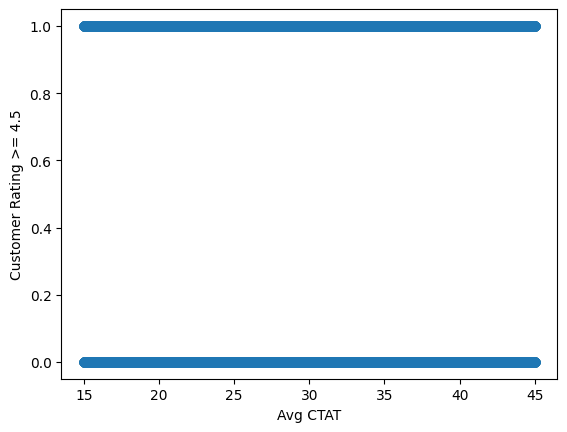

In [311]:
# X[:,1]とYの関係を可視化する。
import matplotlib.pyplot as plt
plt.scatter(X[:,1], Y)
plt.xlabel("Avg CTAT")
plt.ylabel("Customer Rating >= 4.5")
plt.show()

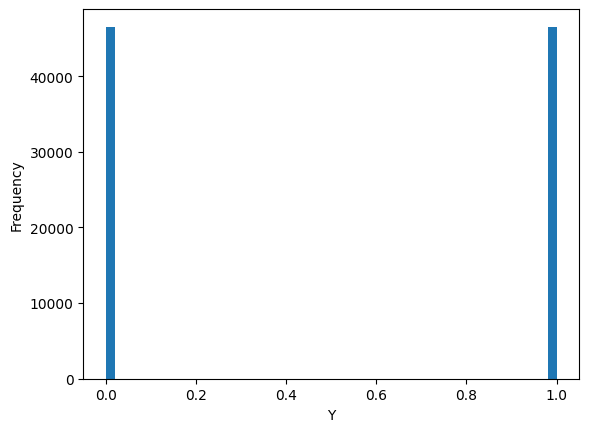

In [312]:
# Yの分布を確認する。
plt.hist(Y, bins=50)
plt.xlabel("Y")
plt.ylabel("Frequency")
plt.show()

In [313]:
# データの分割
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=0)
X_train, X_valid, Y_train, Y_valid = train_test_split(X_train, Y_train, test_size=0.3, random_state=0)

In [314]:
# 形状を確認
print("Y_train=", Y_train.shape, ", X_train=", X_train.shape)
print("Y_valid=", Y_valid.shape, ", X_valid=", X_valid.shape)
print("Y_test=", Y_test.shape, ", X_test=", X_test.shape)

Y_train= (45570,) , X_train= (45570, 14)
Y_valid= (19530,) , X_valid= (19530, 14)
Y_test= (27900,) , X_test= (27900, 14)


In [318]:
# モデルの初期化
model = tf.keras.Sequential([
    # 入力層
    tf.keras.Input(shape=(14,)),
    tf.keras.layers.Dense(2048, activation='relu'),
    # 隠れ層
    tf.keras.layers.Dense(2048, activation='relu'),
    # 隠れ層
    tf.keras.layers.Dense(128, activation='relu'),
    # 隠れ層
    tf.keras.layers.Dense(64, activation='relu'),
    # 出力層
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# モデルの構築
model.compile(optimizer = "rmsprop", loss='binary_crossentropy', metrics=['accuracy'])

In [319]:
model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_64 (Dense)                │ (None, 2048)           │        30,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 2048)           │     4,196,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,497,665 (17.16 MB)

 Trainable params: 4,497,665 (17.16 MB)

 Non-trainable params: 0 (0.00 B)

In [320]:
%%time
# 学習の実施
log = model.fit(X_train, Y_train, epochs=10, batch_size=32, verbose=True,
                callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                            min_delta=0, patience=100,
                                                            verbose=1)],
                validation_data=(X_valid, Y_valid))

Epoch 1/10
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.4992 - loss: 0.9447 - val_accuracy: 0.5034 - val_loss: 0.6931
Epoch 2/10
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.4995 - loss: 0.6934 - val_accuracy: 0.4966 - val_loss: 0.6932
Epoch 3/10
 105/1425 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.4854 - loss: 0.6932CPU times: user 1min 32s, sys: 48.7 s, total: 2min 21s
Wall time: 19.7 s


KeyboardInterrupt: 

Text(0, 0.5, 'crossentropy')

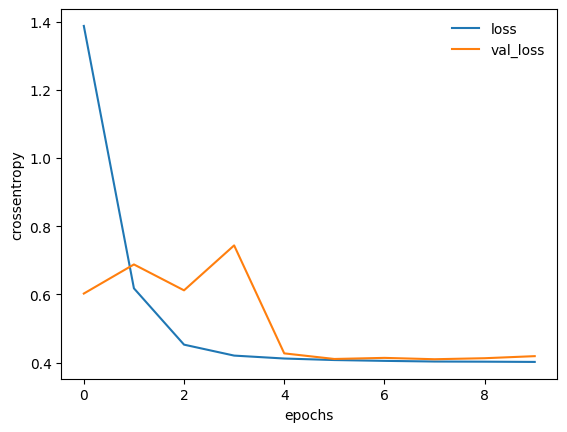

In [262]:
# グラフ表示
plt.plot(log.history['loss'], label='loss')
plt.plot(log.history['val_loss'], label='val_loss')
plt.legend(frameon=False) # 凡例の表示
plt.xlabel("epochs")
plt.ylabel("crossentropy")

In [263]:
# predictで予測を行なう
Y_pred = model.predict(X_test)

872/872 ━━━━━━━━━━━━━━━━━━━━ 0s 209us/step


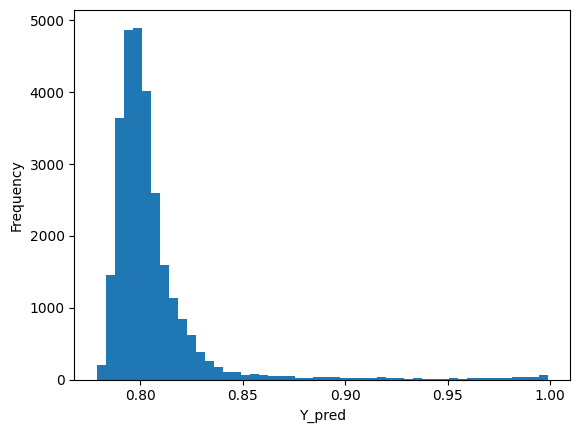

In [264]:
# Y_predの分布を表示
plt.hist(Y_pred, bins=50)
plt.xlabel("Y_pred")
plt.ylabel("Frequency")
plt.show()

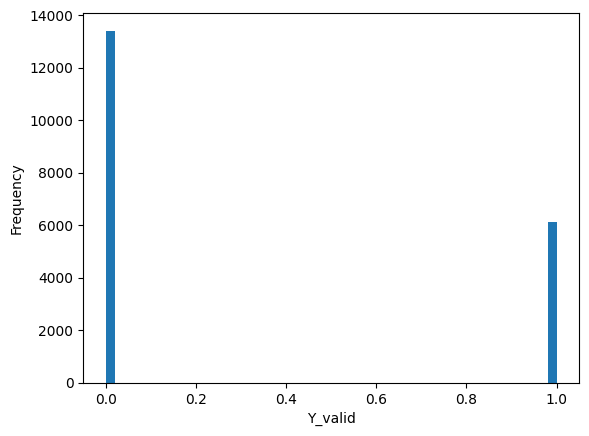

In [209]:
# Y_validの分布を表示
plt.hist(Y_valid, bins=50)
plt.xlabel("Y_valid")
plt.ylabel("Frequency")
plt.show()